In [ ]:
# Filename......: Module_07_Lab_Olis_Bahari_ITAI1371.ipynb
# Language......: Python
# Tools.........: Visual Studio Code (VSC)
# Class.........: ITAI 1371 Introduction to Machine Learning
# Semester......: Summer 2026
# Class Type....: Online
# Instructor....: Sitaram Ayyagari
# Student.......: Olis Bahari
# Version.......: V2.0
# Purpose.......: Learn Supervised Learning using Random Forest Trees,
#                 Confusion Matrix, Accuracy, Precision, Recall, F1-Score,
#                 Average CV Score, and Standard Deviation.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
# Load the Titanic dataset
df = sns.load_dataset('titanic')

# Basic preprocessing
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Setup input and output mapping
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

# Split the data for learning and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest model using multiple decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


Accuracy: 76.22%


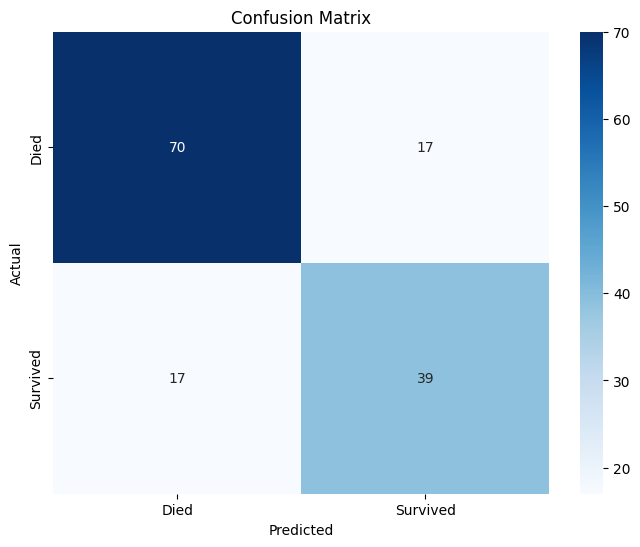

In [ ]:
# Task No 1
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Died', 'Survived'],
    yticklabels=['Died', 'Survived']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Task No. 2
# Classification Report
report = classification_report(y_test, y_pred, target_names=['Died', 'Survived'])
print(report)


              precision    recall  f1-score   support

        Died       0.80      0.80      0.80        87
    Survived       0.70      0.70      0.70        56

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



In [ ]:
# Task No. 3
# Cross-validation Report
cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Scores for each fold: [0.71328671 0.83916084 0.81818182 0.79020979 0.86619718]
Average CV Score: 80.54%
Standard Deviation of CV Scores: 0.0524


📝 Knowledge Check

1. Describe a real-world scenario where you would care more about a model’s Precision than its Recall.

A credit card fraud detection system is an example where precision is more important. If the model incorrectly flags legitimate transactions as fraudulent, customers may have their cards blocked. High precision means fraud predictions are usually correct.


2. Describe a real-world scenario where you would care more about a model’s Recall than its Precision.

A medical screening test for a serious disease is an example where recall is more important. It is better to identify as many people with the disease as possible, even if some healthy people are flagged for additional testing. High recall reduces the chance of missing someone with the disease.

3. Why is a cross-validation score generally more trustworthy than a score from a single train-test split?

Cross-validation is more trustworthy because it evaluates the model on multiple train-test splits rather than a single one. This gives a more reliable estimate of performance and reduces the chance that results are skewed by a lucky or unlucky split.